In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as sfm

In [3]:
df = pd.read_csv('Fuel.csv')

In [3]:
df.head(10)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,2014,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,2014,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,2014,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,2014,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,2014,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


array([[<Axes: title={'center': 'CO2EMISSIONS'}>]], dtype=object)

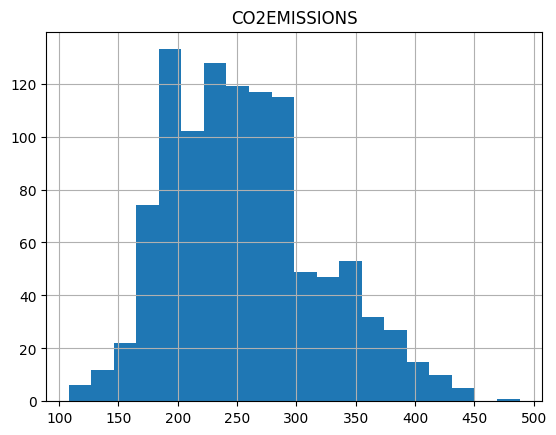

In [4]:
df.hist(column = 'CO2EMISSIONS' , bins = 20)

In [5]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='str')

In [6]:
x = df[['ENGINESIZE' , 'CYLINDERS' , 'FUELCONSUMPTION_CITY' , 'FUELCONSUMPTION_HWY' , 'FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS']

In [7]:
from sklearn.model_selection import train_test_split as tts

In [8]:
xtr , xtes , ytr , ytes = tts(x , y , test_size = 0.2 , random_state = 4)

In [12]:
print('train set shape: ' , xtr.shape , ytr.shape)
print('test set shape: ' , xtes.shape , ytes.shape)

train set shape:  (853, 5) (853,)
test set shape:  (214, 5) (214,)


# 1) 1 variable

In [9]:
data = {

    'x1' : xtr['ENGINESIZE'] , 
    'y' : ytr
}

In [10]:
model = sfm.ols('y ~ x1' , data = data).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     2587.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):          2.88e-260
Time:                        19:24:06   Log-Likelihood:                -4161.3
No. Observations:                 853   AIC:                             8327.
Df Residuals:                     851   BIC:                             8336.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    125.1468      2.791     44.847      0.000     119.670     130.624
x1            39.1169      0.769     50.867      0.000      37.608      40.626
==============================================================================
Omnibus:                       19.917   Durbin-Watson:                   2.064
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.251
Skew:                           0.092   Prob(JB):                     4.94e-09
Kurtosis:                       4.021   Cond. No.                         9.89
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 1.1) Prediction

In [11]:
d = {

    'x1' : xtes['ENGINESIZE']
}

In [12]:
yp = model.predict(d)
yp.head()

834    269.879443
66     203.380650
983    262.056055
849    262.056055
110    297.261299
dtype: float64

# 1.2) checking errors assumptions for 1-variable

In [13]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse

In [14]:
T_error = model.resid

In [15]:
v1_check = {

    'Actual' : ytes , 
    'Predicted' : yp , 
    'Residuals' : ytes - yp
}

In [16]:
MAE = mae(ytes , yp)
MSE = mse(ytes , yp)
RMSE = np.sqrt(MSE)

print('MSE: ' , MSE)
print('MAE: ' , MAE)
print('RMSE: ' , RMSE)

MSE:  687.1851023941664
MAE:  19.979977171018735
RMSE:  26.214215654758135


In [17]:
np.mean(v1_check['Residuals'])

np.float64(0.9222743899867144)

In [18]:
np.mean(T_error)

np.float64(1.4947220223305086e-13)

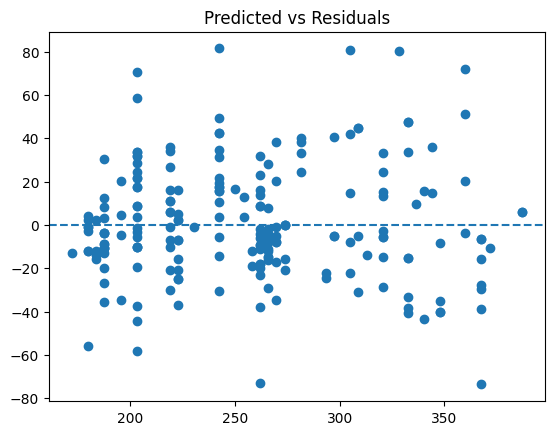

In [19]:
plt.scatter(yp , v1_check['Residuals'])
plt.axhline(y = 0 , linestyle = '--')
plt.title('Predicted vs Residuals')
plt.show()

In [22]:
import statsmodels.api as sm

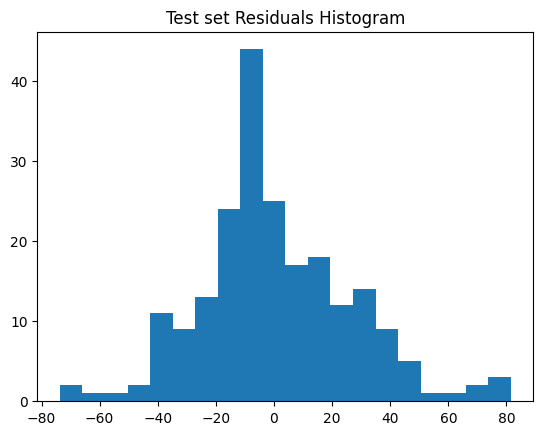

In [20]:
plt.hist(v1_check['Residuals'] , bins = 20)
plt.title('Test set Residuals Histogram')
plt.show()

Text(0.5, 1.0, 'Q-Q Plot of Test set Residuals')

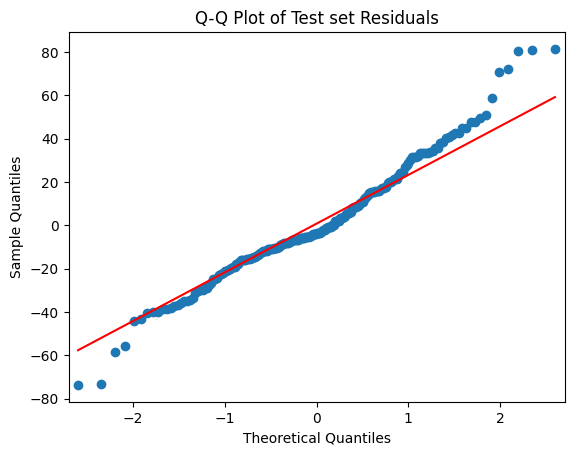

In [23]:
sm.qqplot(v1_check['Residuals'] , line = 'q')
plt.title('Q-Q Plot of Test set Residuals')

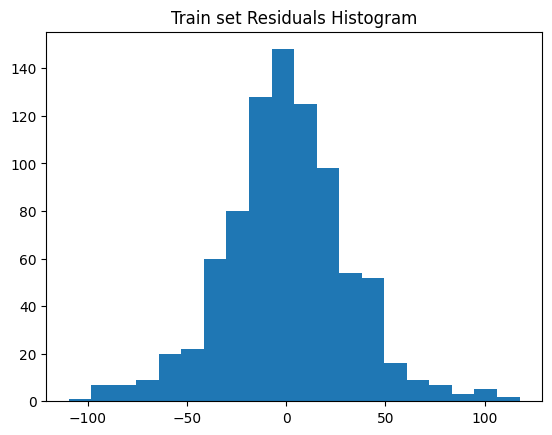

In [24]:
plt.hist(T_error , bins = 20)
plt.title('Train set Residuals Histogram')
plt.show()

Text(0.5, 1.0, 'Q-Q Plot of Train set Residuals')

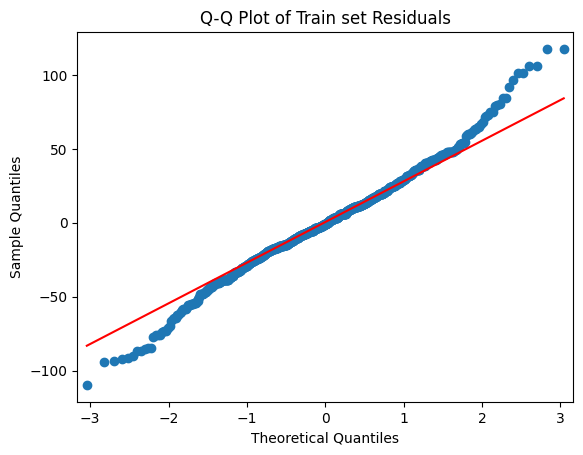

In [25]:
sm.qqplot(T_error , line = 'q')
plt.title('Q-Q Plot of Train set Residuals')

In [26]:
from statsmodels.stats.diagnostic import het_breuschpagan as hb

In [27]:
bp_test = hb(

    model.resid , 
    model.model.exog
)

labels = [

    'LM Statistics' , 
    'LM-Test p-value' , 
    'F-Statistics' , 
    'F-test p-value'
]

In [28]:
for label , value in zip(labels , bp_test):
    print(f'{label} : {value}')

LM Statistics : 48.721417376549105
LM-Test p-value : 2.9502698173619814e-12
F-Statistics : 51.5516974879524
F-test p-value : 1.5208406170917246e-12


In [29]:
robust_model = model.get_robustcov_results(cov_type = 'HC3')
robust_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     1891.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):          2.05e-218
Time:                        19:24:51   Log-Likelihood:                -4161.3
No. Observations:                 853   AIC:                             8327.
Df Residuals:                     851   BIC:                             8336.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    125.1468      2.805     44.608      0.000     119.640     130.653
x1            39.1169      0.900     43.484      0.000      37.351      40.883
==============================================================================
Omnibus:                       19.917   Durbin-Watson:                   2.064
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.251
Skew:                           0.092   Prob(JB):                     4.94e-09
Kurtosis:                       4.021   Cond. No.                         9.89
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

# 2) 2-variable

In [30]:
data2 = {

    'x1' : xtr['ENGINESIZE'] , 
    'x2' : xtr['CYLINDERS'] , 
    'y' : ytr
}

In [31]:
model2 = sfm.ols('y ~ x1 + x2' , data = data2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1355.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):          4.51e-265
Time:                        19:24:56   Log-Likelihood:                -4146.1
No. Observations:                 853   AIC:                             8298.
Df Residuals:                     850   BIC:                             8312.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    107.9202      4.135     26.100      0.000      99.804     116.036
x1            28.0827      2.121     13.238      0.000      23.919      32.246
x2             9.3619      1.682      5.567      0.000       6.061      12.663
==============================================================================
Omnibus:                       17.294   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.031
Skew:                           0.162   Prob(JB):                     1.35e-06
Kurtosis:                       3.809   Cond. No.                         29.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 2.2) Prediction

In [32]:
d2 = {

    'x1' : xtes['ENGINESIZE'] , 
    'x2' : xtes['CYLINDERS'] , 
    'y' : ytes
}

In [34]:
yp2 = model2.predict(d2)

# 2.3) checking error assumptions for 2-variable

In [35]:
v2_check = {

    'Actual' : ytes , 
    'Predicted' : yp2 , 
    'Residuals' : ytes - yp2
}

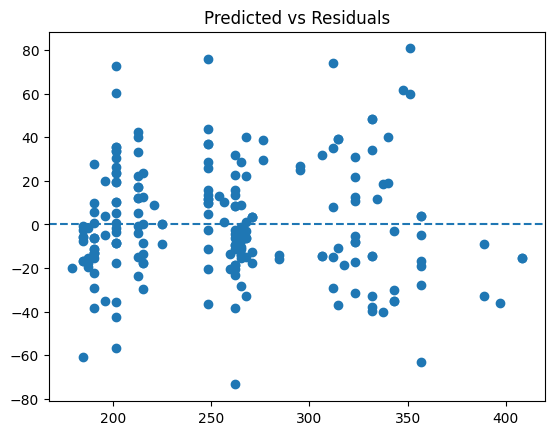

In [36]:
plt.scatter(yp2 , v2_check['Residuals'])
plt.axhline(y = 0 , linestyle = '--')
plt.title('Predicted vs Residuals')
plt.show()

In [37]:
T_error2 = model2.resid

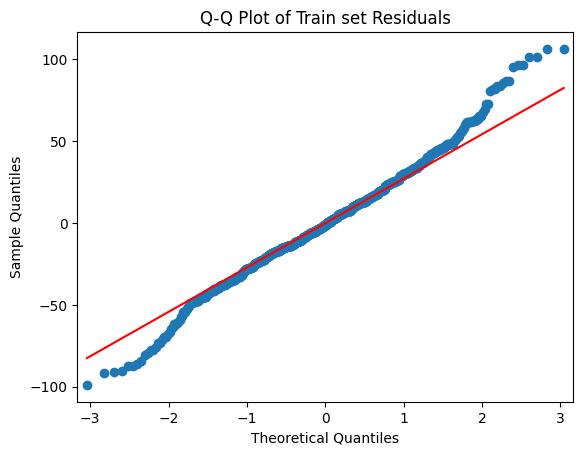

In [38]:
sm.qqplot(T_error2 , line = 'q')
plt.title('Q-Q Plot of Train set Residuals')
plt.show()

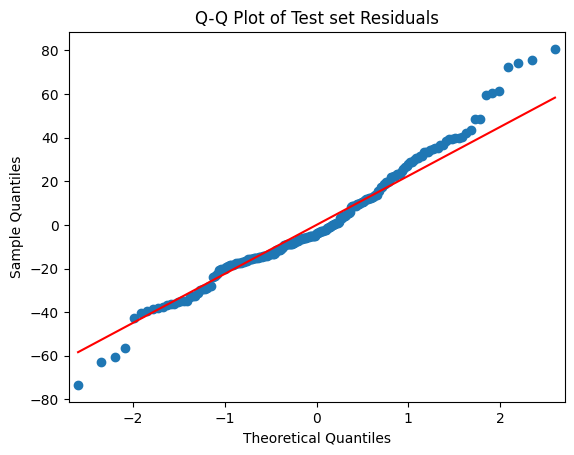

In [39]:
sm.qqplot(v2_check['Residuals'] , line = 'q')
plt.title('Q-Q Plot of Test set Residuals')
plt.show()

In [40]:
MSE2 = mse(ytes, yp2)
MAE2 = mae(ytes , yp2)
RMSE2 = np.sqrt(MSE2)

print('MSE: ' , MSE2)
print('MAE: ' , MAE2)
print('RMSE: ' , RMSE2)

MSE:  656.0318830187017
MAE:  19.832845172904378
RMSE:  25.61311935354032


In [41]:
np.mean(T_error2)

np.float64(2.8971484583512644e-13)

In [42]:
np.mean(v2_check['Residuals'])

np.float64(0.42763327383484173)

In [43]:
bp_test2 = hb(

    model2.resid , 
    model2.model.exog
)

labels = [

    'LM Statistics' , 
    'LM-Test p-value' , 
    'F-Statistics' , 
    'F-test p-value'
]

for label , value in zip(labels , bp_test2):
    print(f'{label} : {value}')

LM Statistics : 49.7652275525577
LM-Test p-value : 1.5617738313375497e-11
F-Statistics : 26.33130740268209
F-test p-value : 8.030169192335481e-12


In [44]:
robust_model2 = model2.get_robustcov_results(cov_type = 'HC3')
robust_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1057.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):          3.27e-231
Time:                        19:25:25   Log-Likelihood:                -4146.1
No. Observations:                 853   AIC:                             8298.
Df Residuals:                     850   BIC:                             8312.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    107.9202      4.186     25.782      0.000      99.704     116.136
x1            28.0827      2.456     11.435      0.000      23.262      32.903
x2             9.3619      1.858      5.040      0.000       5.716      13.008
==============================================================================
Omnibus:                       17.294   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.031
Skew:                           0.162   Prob(JB):                     1.35e-06
Kurtosis:                       3.809   Cond. No.                         29.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

# 3) 3-variable

In [45]:
data3 = {

    'x1' : xtr['ENGINESIZE'] , 
    'x2' : xtr['CYLINDERS'] , 
    'x3' : xtr['FUELCONSUMPTION_CITY'] ,
    'y' : ytr
}

In [46]:
model3 = sfm.ols(' y ~ x1 + x2 + x3' , data = data3).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     1693.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:25:30   Log-Likelihood:                -3927.9
No. Observations:                 853   AIC:                             7864.
Df Residuals:                     849   BIC:                             7883.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     69.8197      3.581     19.496      0.000      62.791      76.849
x1            10.7347      1.798      5.971      0.000       7.206      14.263
x2             6.4179      1.309      4.904      0.000       3.849       8.987
x3             8.5004      0.357     23.809      0.000       7.800       9.201
==============================================================================
Omnibus:                       30.539   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.141
Skew:                          -0.299   Prob(JB):                     3.52e-11
Kurtosis:                       3.999   Cond. No.                         72.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 3.1) Prediction

In [47]:
d3 = {

    'x1' : xtes['ENGINESIZE'] , 
    'x2' : xtes['CYLINDERS'] , 
    'x3' : xtes['FUELCONSUMPTION_CITY'] ,
    'y' : ytes    
}

In [48]:
yp3 = model3.predict(d3)

# 3.2) checking error assumptions for 3-variable 

In [49]:
v3_check = {

    'Actual' : ytes , 
    'Predicted' : yp3 , 
    'Residuals' : ytes - yp3
}

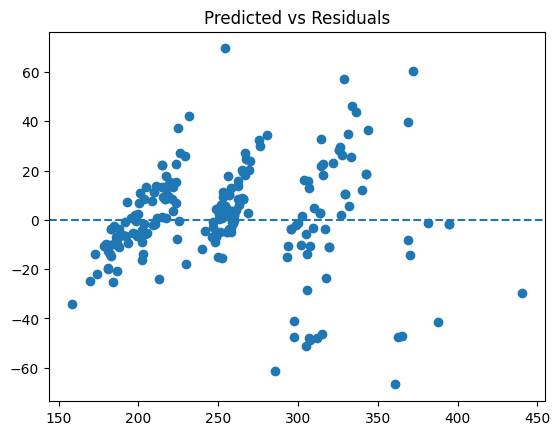

In [50]:
plt.scatter(yp3 , v3_check['Residuals'])
plt.axhline(y = 0 , linestyle = '--')
plt.title('Predicted vs Residuals')
plt.show()

In [51]:
T_error3 = model3.resid

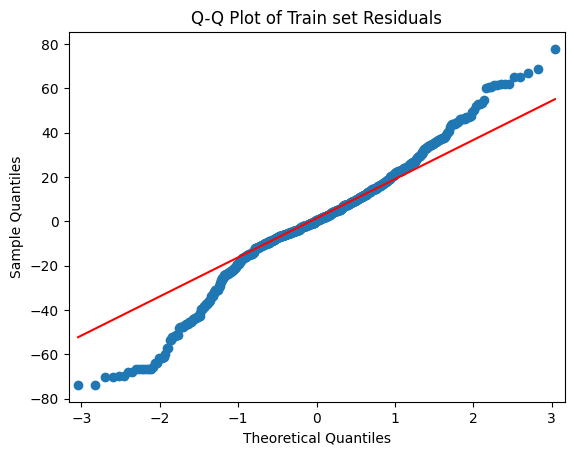

In [52]:
sm.qqplot(T_error3 , line = 'q')
plt.title('Q-Q Plot of Train set Residuals')
plt.show()

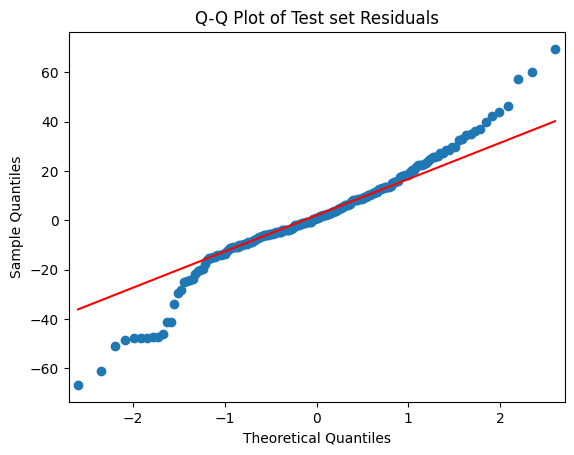

In [53]:
sm.qqplot(v3_check['Residuals'] , line = 'q')
plt.title('Q-Q Plot of Test set Residuals')
plt.show()

In [54]:
MSE3 = mse(ytes, yp3)
MAE3 = mae(ytes, yp3)
RMSE3 = np.sqrt(MSE3)

print('MSE :', MSE3)
print('MAE :', MAE3)
print('RMSE:', RMSE3)

MSE : 414.0287988856514
MAE : 14.567762599069036
RMSE: 20.347697631074908


In [55]:
bp_test3 = hb(

    model3.resid , 
    model3.model.exog
)

labels = [

    'LM Statistics' , 
    'LM-Test p-value' , 
    'F-Statistics' , 
    'F-test p-value'
]

for label , value in zip(labels , bp_test3):
    print(f'{label} : {value}')

LM Statistics : 282.30103952811913
LM-Test p-value : 6.728755781349991e-61
F-Statistics : 139.98832960971205
F-test p-value : 1.0830023134649325e-73


In [56]:
robust_model3 = model3.get_robustcov_results(cov_type = 'HC3')
robust_model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     1368.
Date:                Fri, 21 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:26:36   Log-Likelihood:                -3927.9
No. Observations:                 853   AIC:                             7864.
Df Residuals:                     849   BIC:                             7883.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     69.8197      3.828     18.240      0.000      62.306      77.333
x1            10.7347      1.816      5.912      0.000       7.171      14.299
x2             6.4179      1.207      5.318      0.000       4.049       8.786
x3             8.5004      0.530     16.048      0.000       7.461       9.540
==============================================================================
Omnibus:                       30.539   Durbin-Watson:                   2.027
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.141
Skew:                          -0.299   Prob(JB):                     3.52e-11
Kurtosis:                       3.999   Cond. No.                         72.7
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [58]:
x3 = xtr[['ENGINESIZE' , 'CYLINDERS' , 'FUELCONSUMPTION_CITY']]

In [59]:
Vif = pd.DataFrame()

In [60]:
Vif['Variable'] = x3.columns

In [62]:
Vif['VIF'] = [

    vif(x3.values , i)  
    for i in range(x3.shape[1])
]
Vif

,Variable,VIF
0,ENGINESIZE,41.337078
1,CYLINDERS,55.480140
2,FUELCONSUMPTION_CITY,28.776938


In [63]:
from sklearn.metrics import r2_score

R23 = r2_score(ytes, yp3)

print("R²:", R23)

R²: 0.8885006466093832
